# **EXPLORATORY ANALYSIS**

This is a simple exploratory data analysis (EDA) project implemented as part of the **ADA26 Programming** class.

#### About the dataset

The dataset used in this analysis is [Messy E-Commerce Sales Dataset](https://www.kaggle.com/datasets/kandeelai22/messy-e-commerce-sales-dataset) from _Kaggle_, designed to simulate real-world retail transaction data with intentional data quality issues.

It contains information related to customer purchases, product details, pricing, payment methods, and order outcomes.

#### About the goal

The goal of the analysis is to explore and understand the dataset through basic data preprocessing, visualization, and descriptive statistics.

## **IMPORTS**

For the purpose of this exploratory data analysis (EDA), _Pandas_ is employed for structured data manipulation, whereas _Seaborn_ and _Matplotlib_ are used for data visualization.

In [110]:
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd

## **HELPER FUNCTIONS**

Implementation of simple helper functions used to support the exploratory data analysis (EDA) process.

In [111]:
def is_blank(col):
    col = col.astype("string")
    return pd.isna(col) | (col.str.strip() == "")

def recalculate_total(df):
    df['Total'] = df['Quantity'] * df['Price']

## **DATA**

A key characteristic of this dataset is its **imperfections** and **inconsistencies** - it contains issues such as missing values, inconsistent formatting, outliers, and potential data entry errors, which reflect challenges commonly encountered in real-world datasets.

Overall, this dataset provides a strong foundation for performing **data preprocessing**, **exploratory data analysis**, and **visualization**, while also enabling insights into sales trends, customer behavior, and product performance in an e-commerce context.

In [112]:
ecommerce_dataset = pd.read_csv("./resources/messy_ecommerce_sales_data.csv")

### **Inspecting**

We begin by taking a quick visual look at the dataset to get a general sense of its structure and contents, without performing any detailed analysis.

In [113]:
print("Number of rows in dataset: ", len(ecommerce_dataset))

Number of rows in dataset:  103


In [114]:
ecommerce_dataset.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


In [115]:
ecommerce_dataset.tail()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
98,198,Customer_198,ORD-14608,7/27/2025,Vacuum,NaN,2,497.01,Cash on Delivery,Shipped,994.020
99,199,Customer_199,ORD-82922,1/22/2025,Blender,Home,5,372.28,Credit Card,Shipped,1861.400
100,175,Customer_175,ORD-56651,2/24/2025,Headphones,Electronics,1,111.36,Credit Card,Processing,77.952
101,142,Customer_142,ORD-69018,10/30/2025,Shoes,Clothing,5,645.26,Credit Card,Shipped,3226.300
102,146,Customer_146,ORD-32755,7/9/2025,Basketball,electronic,2,705.42,Bank Transfer,Processing,1410.840


Overview of the dataset columns and their meaning is provided in fallowing table:

| Column Name      | Description                                                                 |
|------------------|-----------------------------------------------------------------------------|
| Customer         | Name of the customer who placed the order                                  |
| Product          | Name of the product that was purchased                                     |
| Category         | Category to which the product belongs (e.g. electronics, clothing)         |
| Price            | Unit price of a single product                                             |
| Quantity         | Number of units of the product purchased in the order                      |
| Total            | Total value of the order calculated as Price multiplied by Quantity        |
| Date             | Date on which the order was placed                                         |
| Payment Method   | Method used by the customer to complete the payment                        |
| Status           | Current status of the order (e.g. completed, pending, canceled)            |


As we can observe from the initial exploration:

- The majority of variables are **categorical (text-based)**
- There are **missing values (NaN)** and some invalid entries present in the dataset

Next step is to inspect column data types, review the overall structure of the dataset, and verify that each column aligns with the data types expected in real-world scenarios.

In [116]:
ecommerce_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              103 non-null    int64  
 1    Customer_Name  103 non-null    str    
 2   Order_ID        103 non-null    str    
 3   Order_Date      103 non-null    str    
 4   Product         103 non-null    str    
 5    Category       95 non-null     str    
 6   Quantity        98 non-null     str    
 7   Price           98 non-null     str    
 8   Payment_Method  103 non-null    str    
 9   Status          103 non-null    str    
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), str(9)
memory usage: 9.0 KB


The following columns require data type corrections or formatting improvements:

* **order_date**: expected *date type*
* **price**: expected *float type*
* **quantity**: expected *integer type*
* **customer_name**, **category**: inconsistent formatting

We can also check the number of unique values in each column, which may provide useful insights into the variability and structure of the data.

In [117]:
ecommerce_dataset.nunique()

ID                100
 Customer_Name    100
Order_ID          100
Order_Date         86
Product            21
 Category           9
Quantity            8
Price              94
Payment_Method      4
Status              5
Total              88
dtype: int64

## **Cleaning**

Now that we are familiar with the dataset and have a better understanding of its structure, we begin the data cleaning process by addressing each column individually.

### **ID, Customer Name, Order ID**

In [118]:
ecommerce_dataset.loc[ecommerce_dataset['ID'].isna(), 'ID']

Series([], Name: ID, dtype: int64)

**ID** is of type integer and contains no missing values, so no changes are required and it can be left as is. However, we should check for duplicate entries.

In [119]:
ecommerce_dataset['ID'].value_counts(sort=True, ascending=False)

ID
142    2
146    2
175    2
100    1
101    1
      ..
195    1
196    1
197    1
198    1
199    1
Name: count, Length: 100, dtype: int64

We observe that some duplicates are present. If the rows are identical across all columns, we will remove them.

In [120]:
duplicated_ids = ecommerce_dataset['ID'].value_counts()[ecommerce_dataset['ID'].value_counts() > 1].index.to_list()
print(duplicated_ids)

ecommerce_dataset.sort_values('ID').loc[ecommerce_dataset['ID'].isin(duplicated_ids), :]

[142, 146, 175]


,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
42,142,Customer_142,ORD-69018,10/30/2025,Shoes,Clothing,5,645.26,Credit Card,Shipped,2258.410
101,142,Customer_142,ORD-69018,10/30/2025,Shoes,Clothing,5,645.26,Credit Card,Shipped,3226.300
102,146,Customer_146,ORD-32755,7/9/2025,Basketball,electronic,2,705.42,Bank Transfer,Processing,1410.840
46,146,Customer_146,ORD-32755,7/9/2025,Basketball,electronic,2,705.42,Bank Transfer,Processing,1410.840
100,175,Customer_175,ORD-56651,2/24/2025,Headphones,Electronics,1,111.36,Credit Card,Processing,77.952
75,175,Customer_175,ORD-56651,2/24/2025,Headphones,Electronics,1,111.36,Credit Card,Processing,111.360


As we can see that the data is identical, we can safely remove the duplicate entries.

In [121]:
ecommerce_dataset = ecommerce_dataset.drop_duplicates(subset="ID", keep="first")

From our initial inspection, we observe that:
- **Customer_Name** contains leading spaces and requires cleaning and/or renaming
- **Category** has the same issue, with leading spaces and inconsistent formatting

In [122]:
ecommerce_dataset = ecommerce_dataset.rename(
    columns={
        " Customer_Name": "Customer_Name",
        " Category": "Category",
    }
)
ecommerce_dataset.loc[is_blank(ecommerce_dataset["Customer_Name"]), "Customer_Name"]

Series([], Name: Customer_Name, dtype: str)

In [185]:
ecommerce_dataset.loc[is_blank(ecommerce_dataset["Order_ID"]), "Order_ID"]

Series([], Name: Order_ID, dtype: str)

### **Order Date**

**Order_Date** is currently stored as a string and should be converted to a date type

In [124]:
ecommerce_dataset.loc[pd.to_datetime(ecommerce_dataset['Order_Date'], errors='coerce').isna(), 'Order_Date']

14    Jan 5 2023
92           abc
Name: Order_Date, dtype: str

* The first date format (e.g., "Jan 5 2023") is valid and can be parsed correctly
* Invalid values (e.g., "abc") cannot be converted and will be set to NaT

In [125]:
ecommerce_dataset.loc[ecommerce_dataset['Order_Date'] == "Jan 5 2023", 'Order_Date'] = "1/5/2023"
ecommerce_dataset.loc[pd.to_datetime(ecommerce_dataset['Order_Date'], errors='coerce').isna(), 'Order_Date']

92    abc
Name: Order_Date, dtype: str

Converting **Order_Date** to a proper date type

In [126]:
ecommerce_dataset['Order_Date'] = pd.to_datetime(ecommerce_dataset['Order_Date'], errors='coerce')
ecommerce_dataset['Order_Date'].dtype

dtype('<M8[us]')

### **Product**

Checking the **Product** column for missing values or inconsistencies

In [127]:
print(ecommerce_dataset.loc[is_blank(ecommerce_dataset["Product"]), "Product"])
ecommerce_dataset["Product"].value_counts()

Series([], Name: Product, dtype: str)


Product
Blender          8
Tennis Racket    7
Basketball       7
Comics           7
Shoes            7
Lamp             7
Science          6
Smartphone       5
Biography        5
Fiction          5
Microwave        5
Yoga Mat         5
Vacuum           5
Laptop           4
T-shirt          3
Smartwatch       3
Jacket           3
Jeans            3
Headphones       2
Football         2
shoes            1
Name: count, dtype: int64

### **Category**

Performing the same checks on the **Category** column

In [128]:
print(ecommerce_dataset.loc[is_blank(ecommerce_dataset["Category"]), "Category"])
ecommerce_dataset["Category"].value_counts()

33    NaN
36    NaN
80    NaN
81    NaN
82    NaN
84    NaN
93    NaN
98    NaN
Name: Category, dtype: str


Category
Books          22
Home           20
Sports         16
Clothing       14
Electronics    10
electronic      3
ELECTRONICS     3
electronics     3
sports          1
Name: count, dtype: int64

Two issues are noticeable here:
* Some categories have the same name but different letter casing
* Some values in the **Category** column are NaN (missing)

In [129]:
# convert case
ecommerce_dataset["Category"] = ecommerce_dataset["Category"].replace(
    {"Electronic": "Electronics"}
)
ecommerce_dataset['Category'] = ecommerce_dataset['Category'].str.capitalize()
ecommerce_dataset["Category"].value_counts()

Category
Books          22
Home           20
Sports         17
Electronics    16
Clothing       14
Electronic      3
Name: count, dtype: int64

Missing values in the **Category** column can be imputed by using the **Product** column as a reference. Products that already have an assigned category can be used to fill in missing values for the same product, ensuring consistency across the dataset.

In [130]:
product_to_category_map = (
    ecommerce_dataset.dropna(subset=["Category"]).drop_duplicates(subset=["Product"]).set_index("Product")["Category"]
)
print(f"{product_to_category_map.head()}\n")

ecommerce_dataset["Category"] = ecommerce_dataset["Category"].fillna(ecommerce_dataset["Product"].map(product_to_category_map))
print(ecommerce_dataset.loc[is_blank(ecommerce_dataset["Category"]), "Category"])

Product
Blender                 Home
Smartphone       Electronics
Tennis Racket         Sports
Science                Books
Biography              Books
Name: Category, dtype: str

Series([], Name: Category, dtype: str)


### **Quantity**

The **Quantity** column is the next to be checked for data quality issues.

In [131]:
print(ecommerce_dataset["Quantity"].agg(['min', 'max']))
ecommerce_dataset.loc[pd.to_numeric(ecommerce_dataset['Quantity'], errors='coerce').isna(), 'Quantity']

min    -2
max     5
Name: Quantity, dtype: str


6     NaN
64    NaN
67    NaN
92     4a
93    NaN
96    NaN
Name: Quantity, dtype: str

Here we observe several data quality problems in the **Quantity** column:

* Presence of negative values
* Some NaN (missing) values
* One string value
* The column is currently stored as string type, but should be integer

First, we inspect the unexpected string value ("4a").

In [132]:
ecommerce_dataset.loc[ecommerce_dataset['Quantity'] == '4a', :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
92,192,Customer_192,ORD-35144,NaT,Jacket,Clothing,4a,203.63,Credit Card,Returned,NaN


All noisy or inconsistent values in the **Quantity** column are converted into a proper numeric format. Invalid entries are coerced into NaN, and the column is standardized to a numeric type for further analysis.

In [133]:
ecommerce_dataset["Quantity"] = (
    ecommerce_dataset["Quantity"]
    .astype(str)
    .str.extract(r"(-?\d+)")
    .astype(float)
)
ecommerce_dataset.loc[pd.to_numeric(ecommerce_dataset['Quantity'], errors='coerce').isna(), 'Quantity']

6    NaN
64   NaN
67   NaN
93   NaN
96   NaN
Name: Quantity, dtype: float64

Some of the missing (NaN) values in the **Quantity** column can be inferred using available data and logical relationships in the dataset (based on the formula/derived fields).

$Quantity * Price = Total Price$

In [134]:
ecommerce_dataset.loc[pd.to_numeric(ecommerce_dataset['Quantity'], errors='coerce').isna(), ['Quantity', 'Price', 'Total']]

,Quantity,Price,Total
6,NaN,978.63,NaN
64,NaN,587.64,NaN
67,NaN,593.93,NaN
93,NaN,522.02,NaN
96,NaN,abd,NaN


In this case, some values cannot be reliably inferred. There is also one fully invalid row where:

* quantity is NaN
* total is NaN
* price contains a non-numeric value ("abd")

Since there is no reliable way to reconstruct this record, it may be removed after type conversion.

For now, we convert all valid values in the quantity column to integer type, coercing invalid entries where necessary.

In [135]:
ecommerce_dataset['Quantity'] = pd.to_numeric(ecommerce_dataset['Quantity'], errors='coerce')
ecommerce_dataset['Quantity'].dtype

dtype('float64')

An additional issue in the **Quantity** column is the presence of negative values, which are not valid in this context.

These values need to be reviewed, as they may represent data entry errors or inconsistent records.

In [136]:
ecommerce_dataset[ecommerce_dataset['Quantity'] <= 0]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
17,117,Customer_117,ORD-72751,2025-02-12,Blender,Electronic,-2.0,10000,Cash on Delivery,Processing,-20000.00
34,134,Customer_134,ORD-16585,2025-10-04,T-shirt,Clothing,-5.0,591.53,PayPal,Shipped,-2957.65


Negative values in the **Quantity** column are considered noise in this dataset.

These values will be converted to their absolute (positive) equivalents to ensure consistency and validity of the data.

In [137]:
ecommerce_dataset["Quantity"] = ecommerce_dataset["Quantity"].abs()
ecommerce_dataset["Quantity"].agg(['min', 'max'])

min    1.0
max    5.0
Name: Quantity, dtype: float64

### **Price**

In [138]:
print(ecommerce_dataset["Price"].agg(['min', 'max']))
ecommerce_dataset.loc[pd.to_numeric(ecommerce_dataset['Price'], errors='coerce').isna(), 'Price']

min            -100
max    four hundred
Name: Price, dtype: str


1              abd
10    four hundred
16             NaN
20            300$
24             NaN
30             NaN
56             NaN
83             NaN
96             abd
Name: Price, dtype: str

The **Price** column contains several data quality issues:
* Presence of NaN (missing) values
* Some entries contain textual (non-numeric) data
* Some values include currency symbols or formatting
* The column is currently stored as a string type, but should be converted to a float

In [139]:
ecommerce_dataset.loc[ecommerce_dataset['Price'] == 'four hundred', :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
10,110,Customer_110,ORD-61020,2025-09-26,Basketball,Sports,5.0,four hundred,Cash on Delivery,Cancelled,NaN


In [140]:
ecommerce_dataset.loc[ecommerce_dataset['Price'] == "four hundred", 'Price'] = "400"
ecommerce_dataset.loc[ecommerce_dataset['Price'] == "300$", 'Price'] = "300"

For the non-numeric value ("abd"), we inspect the corresponding row across related columns to assess its impact and determine whether it can be corrected or should be removed.

In [141]:
ecommerce_dataset.loc[pd.to_numeric(ecommerce_dataset['Price'], errors='coerce').isna(), :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2.0,abd,PayPal,Processing,NaN
16,116,Customer_116,ORD-63660,2025-10-30,Microwave,Home,4.0,NaN,Cash on Delivery,Processing,NaN
24,124,Customer_124,ORD-46136,2025-05-31,Comics,Books,5.0,NaN,PayPal,Cancelled,NaN
30,130,Customer_130,ORD-34007,2025-08-15,Tennis Racket,Sports,2.0,NaN,Bank Transfer,Processing,NaN
56,156,Customer_156,ORD-34679,2024-11-28,Jeans,Clothing,2.0,NaN,Bank Transfer,Shipped,NaN
83,183,Customer_183,ORD-20916,2025-03-10,Shoes,Clothing,5.0,NaN,Cash on Delivery,Returned,NaN
96,196,Customer_196,ORD-78384,2024-12-23,Vacuum,Home,NaN,abd,PayPal,Delivered,NaN


The **Price** column is converted to a numeric type, with non-numeric values (e.g., "abd") coerced to NaN for further handling.

In [142]:
ecommerce_dataset['Price'] = pd.to_numeric(ecommerce_dataset['Price'], errors='coerce')
ecommerce_dataset['Price'].dtypes

dtype('float64')

In [143]:
ecommerce_dataset["Price"] = ecommerce_dataset["Price"].abs()
ecommerce_dataset["Price"].agg(['min', 'max'])

min       38.0
max    10000.0
Name: Price, dtype: float64

### **Payment Method, Status**

In [144]:
print(ecommerce_dataset.loc[is_blank(ecommerce_dataset["Payment_Method"]), "Payment_Method"])
ecommerce_dataset["Payment_Method"].value_counts()

Series([], Name: Payment_Method, dtype: str)


Payment_Method
Cash on Delivery    33
PayPal              24
Bank Transfer       22
Credit Card         21
Name: count, dtype: int64

In [145]:
print(ecommerce_dataset.loc[is_blank(ecommerce_dataset["Status"]), "Status"])
ecommerce_dataset["Status"].value_counts()

Series([], Name: Status, dtype: str)


Status
Returned      27
Processing    25
Shipped       22
Cancelled     15
Delivered     11
Name: count, dtype: int64

The **Payment_Method** and **Status** columns are clean and require no further processing.

### **Total**

In [146]:
print(ecommerce_dataset["Total"].agg(['min', 'max']))
ecommerce_dataset.loc[ecommerce_dataset['Total'].isna(), 'Total']

min   -20000.0
max     4722.7
Name: Total, dtype: float64


1    NaN
6    NaN
10   NaN
16   NaN
20   NaN
24   NaN
30   NaN
56   NaN
64   NaN
67   NaN
83   NaN
92   NaN
93   NaN
96   NaN
Name: Total, dtype: float64

The total column contains the following data quality issues:
* Presence of negative values
* Presence of NaN (missing) values

In [147]:
ecommerce_dataset[ecommerce_dataset['Total'] <= 0]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
17,117,Customer_117,ORD-72751,2025-02-12,Blender,Electronic,2.0,10000.00,Cash on Delivery,Processing,-20000.00
34,134,Customer_134,ORD-16585,2025-10-04,T-shirt,Clothing,5.0,591.53,PayPal,Shipped,-2957.65
37,137,Customer_137,ORD-91254,2025-02-23,Vacuum,Home,3.0,100.00,Cash on Delivery,Delivered,-300.00


Negative values in the **Total** column are converted to their absolute values, as they likely originate from incorrect values in **Quantity** or **Price**.

However, since **Total** is a derived column, it will be recalculated to ensure full consistency and accuracy.

In [148]:
ecommerce_dataset.loc[ecommerce_dataset['Total'].isna(), :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2.0,NaN,PayPal,Processing,NaN
6,106,Customer_106,ORD-25885,2025-02-02,Blender,Home,NaN,978.63,Bank Transfer,Processing,NaN
10,110,Customer_110,ORD-61020,2025-09-26,Basketball,Sports,5.0,400.00,Cash on Delivery,Cancelled,NaN
16,116,Customer_116,ORD-63660,2025-10-30,Microwave,Home,4.0,NaN,Cash on Delivery,Processing,NaN
20,120,Customer_120,ORD-14659,2025-06-13,Yoga Mat,Electronics,5.0,300.00,Credit Card,Cancelled,NaN
24,124,Customer_124,ORD-46136,2025-05-31,Comics,Books,5.0,NaN,PayPal,Cancelled,NaN
30,130,Customer_130,ORD-34007,2025-08-15,Tennis Racket,Sports,2.0,NaN,Bank Transfer,Processing,NaN
56,156,Customer_156,ORD-34679,2024-11-28,Jeans,Clothing,2.0,NaN,Bank Transfer,Shipped,NaN
64,164,Customer_164,ORD-23010,2025-02-09,Tennis Racket,Sports,NaN,587.64,Credit Card,Returned,NaN
67,167,Customer_167,ORD-30329,2025-08-07,Basketball,Sports,NaN,593.93,Cash on Delivery,Processing,NaN


Some rows contain NaN values in **Total** despite having valid quantity and price. In these cases, the missing values can be computed using the formula:

$Quantity * Price = Total Price$.

To ensure consistency and eliminate errors, the entire **Total** column will be recalculated based on this relationship.

In [149]:
recalculate_total(ecommerce_dataset)
ecommerce_dataset.loc[ecommerce_dataset['Total'].isna(), :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2.0,NaN,PayPal,Processing,NaN
6,106,Customer_106,ORD-25885,2025-02-02,Blender,Home,NaN,978.63,Bank Transfer,Processing,NaN
16,116,Customer_116,ORD-63660,2025-10-30,Microwave,Home,4.0,NaN,Cash on Delivery,Processing,NaN
24,124,Customer_124,ORD-46136,2025-05-31,Comics,Books,5.0,NaN,PayPal,Cancelled,NaN
30,130,Customer_130,ORD-34007,2025-08-15,Tennis Racket,Sports,2.0,NaN,Bank Transfer,Processing,NaN
56,156,Customer_156,ORD-34679,2024-11-28,Jeans,Clothing,2.0,NaN,Bank Transfer,Shipped,NaN
64,164,Customer_164,ORD-23010,2025-02-09,Tennis Racket,Sports,NaN,587.64,Credit Card,Returned,NaN
67,167,Customer_167,ORD-30329,2025-08-07,Basketball,Sports,NaN,593.93,Cash on Delivery,Processing,NaN
83,183,Customer_183,ORD-20916,2025-03-10,Shoes,Clothing,5.0,NaN,Cash on Delivery,Returned,NaN
93,193,Customer_193,ORD-42475,2025-06-06,Basketball,Sports,NaN,522.02,PayPal,Shipped,NaN


### **Re-check**

The dataset is reviewed once more after all cleaning steps to ensure data consistency, correct data types, and absence of major data quality issues.

In [150]:
ecommerce_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID              100 non-null    int64         
 1   Customer_Name   100 non-null    str           
 2   Order_ID        100 non-null    str           
 3   Order_Date      99 non-null     datetime64[us]
 4   Product         100 non-null    str           
 5   Category        100 non-null    str           
 6   Quantity        95 non-null     float64       
 7   Price           93 non-null     float64       
 8   Payment_Method  100 non-null    str           
 9   Status          100 non-null    str           
 10  Total           89 non-null     float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(6)
memory usage: 8.7 KB


In [151]:
ecommerce_dataset.nunique()

ID                100
Customer_Name     100
Order_ID          100
Order_Date         84
Product            21
Category            6
Quantity            5
Price              93
Payment_Method      4
Status              5
Total              89
dtype: int64

In [152]:
ecommerce_dataset.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3.0,38.00,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2.0,NaN,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,1.0,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,2025-03-19,Science,Books,5.0,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,1.0,552.51,Cash on Delivery,Processing,552.51


## **OUTLIERS**

In [153]:
ecommerce_dataset[["Quantity", "Price", "Total"]].describe()

,Quantity,Price,Total
count,95.000000,93.000000,89.000000
mean,3.084211,613.539892,1775.348764
std,1.506462,1017.720450,2273.346277
min,1.000000,38.000000,40.950000
25%,2.000000,275.100000,696.710000
50%,3.000000,531.060000,1362.760000
75%,5.000000,736.710000,2355.920000
max,5.000000,10000.000000,20000.000000


The maximum value in the **Price** column is significantly higher than the 75th percentile, indicating the presence of outliers.

Similar behavior is observed in the **Total** column; however, since total is a derived field, these outliers are likely driven by extreme values in price or quantity.

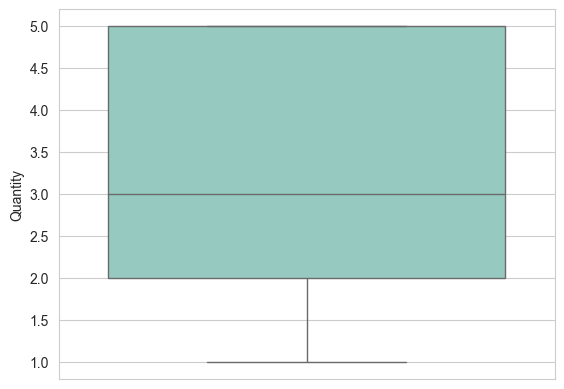

In [154]:
sn.set_style("whitegrid")

sn.boxplot(ecommerce_dataset["Quantity"].dropna(), flierprops={"marker": "o", "markersize": 5})
plt.xticks(rotation=45)
plt.show()

No significant outliers are observed in the **Quantity** column, indicating a relatively consistent distribution of values.

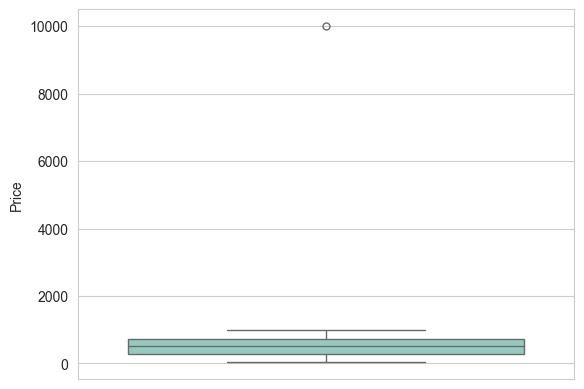

In [155]:
sn.boxplot(ecommerce_dataset["Price"].dropna(), flierprops={"marker": "o", "markersize": 5})
plt.xticks(rotation=45)
plt.show()

A clear outlier is observed in the **Price** column. Since this represents a core financial value, it should not be capped or adjusted artificially.

This row is considered invalid data and will be removed from the dataset to maintain accuracy and integrity of the analysis.

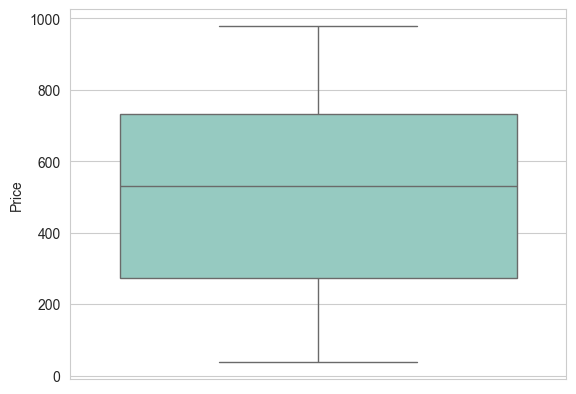

In [156]:
Q1 = ecommerce_dataset["Price"].quantile(0.25)
Q3 = ecommerce_dataset["Price"].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
ecommerce_dataset = ecommerce_dataset[ ecommerce_dataset["Price"].isna() | (ecommerce_dataset["Price"] <= upper_limit)]

sn.boxplot(ecommerce_dataset["Price"].dropna(), flierprops={"marker": "o", "markersize": 5})
plt.xticks(rotation=45)
plt.show()

After removing the invalid price outlier and cleaning the dataset, the **Total** column should be consistent.

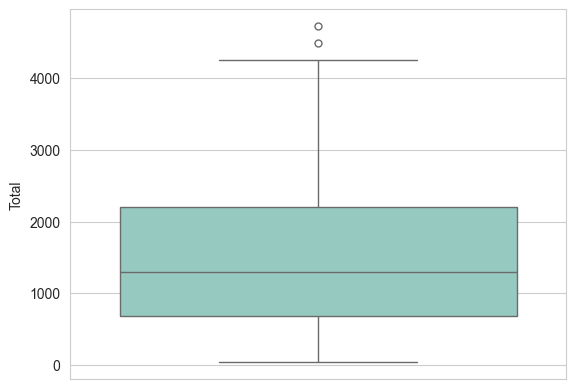

In [157]:
sn.boxplot(ecommerce_dataset["Total"].dropna(), flierprops={"marker": "o", "markersize": 5})
plt.xticks(rotation=45)
plt.show()

One remaining outlier has been identified and requires further inspection to determine whether it is valid or should be removed.

In [158]:
Q1 = ecommerce_dataset["Total"].quantile(0.25)
Q3 = ecommerce_dataset["Total"].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
ecommerce_dataset.loc[ecommerce_dataset["Total"] > upper_limit, :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
49,149,Customer_149,ORD-95911,2025-06-29,Comics,Books,5.0,896.38,Bank Transfer,Cancelled,4481.9
94,194,Customer_194,ORD-69764,2025-02-10,Lamp,Home,5.0,944.54,Cash on Delivery,Returned,4722.7


The remaining outlier is retained after inspection. Although it is an extreme value, it is plausible in context (e.g., a large order of a more expensive product or a potentially fraudulent transaction).

Therefore, it is kept in the dataset for further analysis rather than being removed.

## **IMPUTING**

### **Order Date**

The **Order_Date** column contains only a small number of missing values, which will be ignored for now as they are not expected to significantly impact the analysis.

In [159]:
ecommerce_dataset.loc[ecommerce_dataset['Order_Date'].isna(), 'Order_Date']

92   NaT
Name: Order_Date, dtype: datetime64[us]

### **Category**

The **Category** column has already been successfully imputed, and missing values have been filled based on available product-category mappings.

In [160]:
ecommerce_dataset.loc[ecommerce_dataset['Category'].isna(), 'Category']

Series([], Name: Category, dtype: str)

### **Quantity**

In [161]:
ecommerce_dataset.loc[ecommerce_dataset['Quantity'].isna(), :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
6,106,Customer_106,ORD-25885,2025-02-02,Blender,Home,NaN,978.63,Bank Transfer,Processing,NaN
64,164,Customer_164,ORD-23010,2025-02-09,Tennis Racket,Sports,NaN,587.64,Credit Card,Returned,NaN
67,167,Customer_167,ORD-30329,2025-08-07,Basketball,Sports,NaN,593.93,Cash on Delivery,Processing,NaN
93,193,Customer_193,ORD-42475,2025-06-06,Basketball,Sports,NaN,522.02,PayPal,Shipped,NaN
96,196,Customer_196,ORD-78384,2024-12-23,Vacuum,Home,NaN,NaN,PayPal,Delivered,NaN


In [162]:
ecommerce_dataset.loc[ecommerce_dataset['Product'] == 'Blender', :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3.0,38.00,Cash on Delivery,Shipped,114.00
6,106,Customer_106,ORD-25885,2025-02-02,Blender,Home,NaN,978.63,Bank Transfer,Processing,NaN
27,127,Customer_127,ORD-65482,2025-05-12,Blender,Home,5.0,336.02,Bank Transfer,Returned,1680.10
54,154,Customer_154,ORD-95990,2025-02-21,Blender,Home,5.0,789.64,Cash on Delivery,Cancelled,3948.20
62,162,Customer_162,ORD-27743,2025-05-19,Blender,Home,2.0,155.76,Credit Card,Returned,311.52
97,197,Customer_197,ORD-79139,2025-06-23,Blender,Home,1.0,160.16,PayPal,Cancelled,160.16
99,199,Customer_199,ORD-82922,2025-01-22,Blender,Home,5.0,372.28,Credit Card,Shipped,1861.40


In [163]:
ecommerce_dataset["Quantity"].describe()

count    94.000000
mean      3.095745
std       1.510317
min       1.000000
25%       2.000000
50%       3.000000
75%       5.000000
max       5.000000
Name: Quantity, dtype: float64

-0.4946764362797017


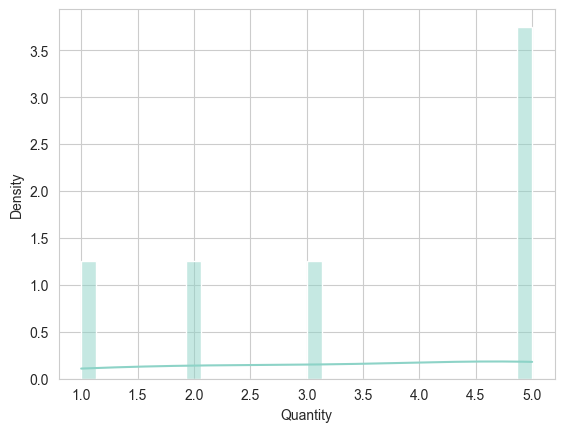

In [164]:
print(ecommerce_dataset[ecommerce_dataset['Product'] == 'Blender']["Quantity"].skew())

sn.histplot(ecommerce_dataset[ecommerce_dataset['Product'] == 'Blender']["Quantity"], bins=30, kde=True, stat="density")
plt.show()

Missing values in the **Quantity** column will be imputed using the median value within the corresponding product group (e.g., Blenders).

This approach is chosen because the distribution is skewed, making the median a more robust measure than the mean for imputation.

In [165]:
ecommerce_dataset["Quantity"] = ecommerce_dataset["Quantity"].fillna(
    ecommerce_dataset.groupby("Product")["Quantity"].transform("median")
)

ecommerce_dataset.loc[ecommerce_dataset['Quantity'].isna(), :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total


The newly imputed values are checked to ensure that the **Quantity** column is now consistent and free of missing entries introduced earlier.

In [166]:
ecommerce_dataset.loc[ecommerce_dataset['Product'] == 'Blender', :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3.0,38.00,Cash on Delivery,Shipped,114.00
6,106,Customer_106,ORD-25885,2025-02-02,Blender,Home,4.0,978.63,Bank Transfer,Processing,NaN
27,127,Customer_127,ORD-65482,2025-05-12,Blender,Home,5.0,336.02,Bank Transfer,Returned,1680.10
54,154,Customer_154,ORD-95990,2025-02-21,Blender,Home,5.0,789.64,Cash on Delivery,Cancelled,3948.20
62,162,Customer_162,ORD-27743,2025-05-19,Blender,Home,2.0,155.76,Credit Card,Returned,311.52
97,197,Customer_197,ORD-79139,2025-06-23,Blender,Home,1.0,160.16,PayPal,Cancelled,160.16
99,199,Customer_199,ORD-82922,2025-01-22,Blender,Home,5.0,372.28,Credit Card,Shipped,1861.40


### **Price**

In [167]:
ecommerce_dataset.loc[ecommerce_dataset['Price'].isna(), :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2.0,NaN,PayPal,Processing,NaN
16,116,Customer_116,ORD-63660,2025-10-30,Microwave,Home,4.0,NaN,Cash on Delivery,Processing,NaN
24,124,Customer_124,ORD-46136,2025-05-31,Comics,Books,5.0,NaN,PayPal,Cancelled,NaN
30,130,Customer_130,ORD-34007,2025-08-15,Tennis Racket,Sports,2.0,NaN,Bank Transfer,Processing,NaN
56,156,Customer_156,ORD-34679,2024-11-28,Jeans,Clothing,2.0,NaN,Bank Transfer,Shipped,NaN
83,183,Customer_183,ORD-20916,2025-03-10,Shoes,Clothing,5.0,NaN,Cash on Delivery,Returned,NaN
96,196,Customer_196,ORD-78384,2024-12-23,Vacuum,Home,2.5,NaN,PayPal,Delivered,NaN


Similar to the **Quantity** column, some missing values are also present in this column.

These will be addressed using an appropriate imputation strategy to ensure consistency across the dataset.

Smartphone
0.20359491832098223


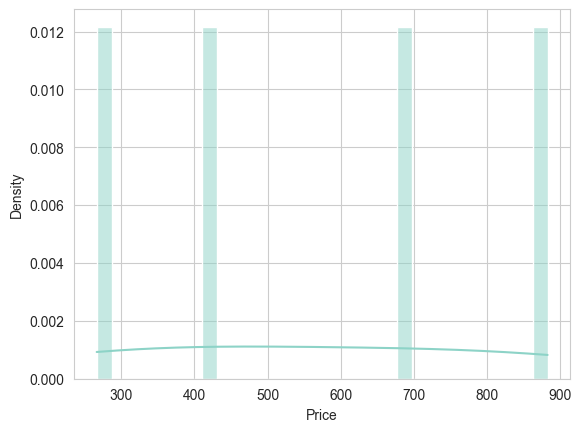

Microwave
0.044510812635837914


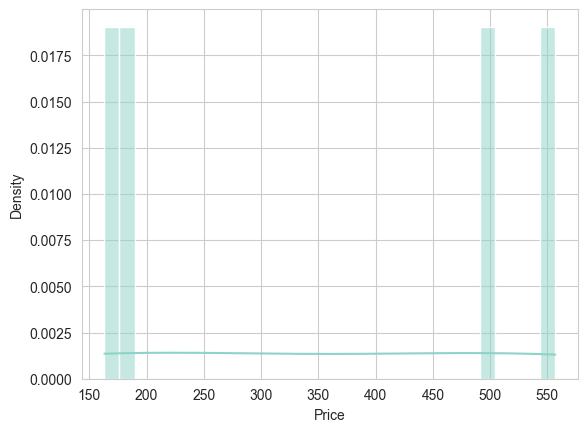

Comics
-0.7014437858104713


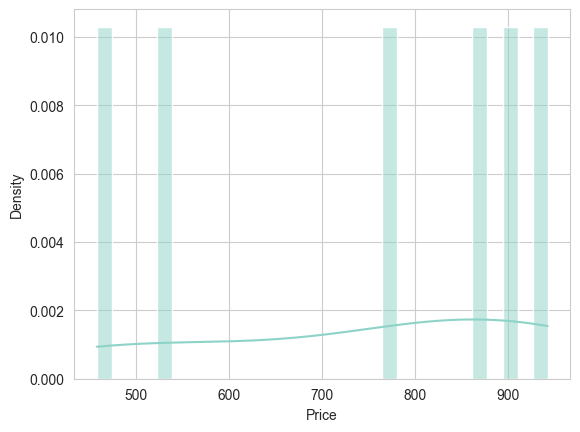

Tennis Racket
-0.2623825018547438


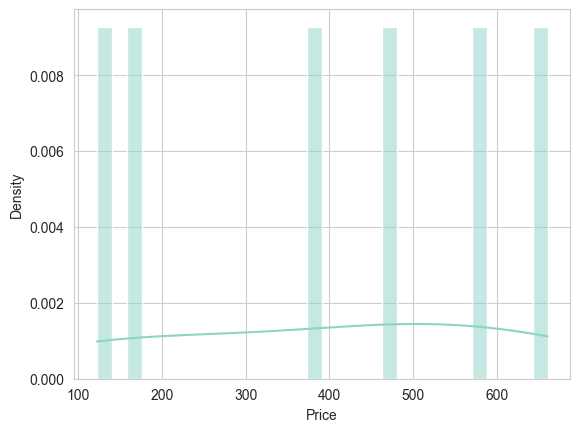

Jeans
nan


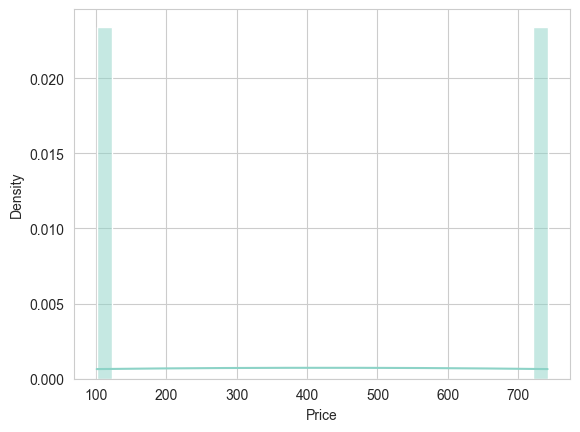

Shoes
-0.2904999959705152


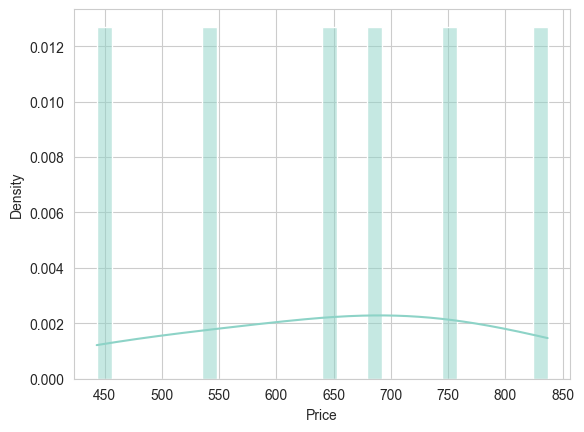

Vacuum
-0.38969376286713137


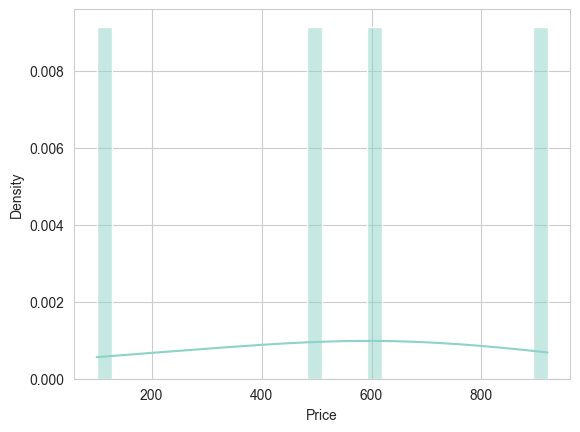

In [168]:
missing_prices = ecommerce_dataset.loc[ecommerce_dataset["Price"].isna(), :]

for product in missing_prices["Product"].unique():
    print(product)
    print(ecommerce_dataset[ecommerce_dataset['Product'] == product]["Price"].skew())
    sn.histplot(ecommerce_dataset[ecommerce_dataset['Product'] == product]["Price"], bins=30, kde=True, stat="density")
    plt.show()

The Jeans product group returned a suspicious result, with missing values (NaN) affecting the calculated statistics due to skewed distribution and insufficient valid data.

This group is being further inspected to determine whether the issue is caused by data quality problems or a lack of representative values.

In [169]:
ecommerce_dataset.loc[ecommerce_dataset['Product'] == 'Jeans', :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
56,156,Customer_156,ORD-34679,2024-11-28,Jeans,Clothing,2.0,NaN,Bank Transfer,Shipped,NaN
70,170,Customer_170,ORD-21530,2025-10-03,Jeans,Clothing,5.0,741.63,Bank Transfer,Processing,3708.15
84,184,Customer_184,ORD-67799,2025-02-15,Jeans,Clothing,4.0,101.19,Bank Transfer,Processing,404.76


The Jeans category contains a very small number of records, which may explain the unstable or unreliable aggregated results. We will inspect the **Category** column (Clothing) to verify which values correspond to Jeans, in order to correctly compute the median for imputation.

-0.6577539776992292


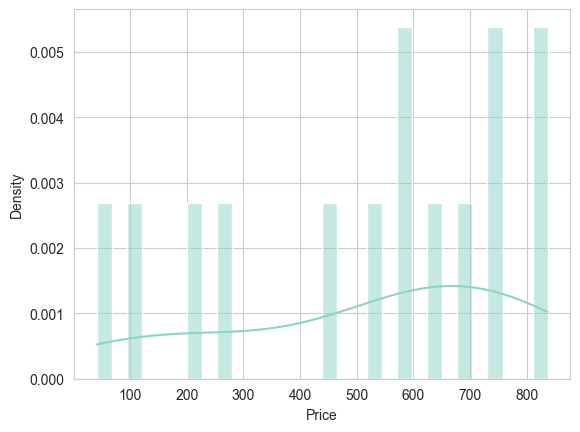

In [170]:
print(ecommerce_dataset[ecommerce_dataset['Category'] == 'Clothing']["Price"].skew())
sn.histplot(ecommerce_dataset[ecommerce_dataset['Category'] == 'Clothing']["Price"], bins=30, kde=True, stat="density")
plt.show()

To handle missing values more robustly, different grouping strategies are applied:
* For Jeans, missing values will be imputed using the median of the category group, due to the limited number of records in this product group
* For all other products, missing values will be imputed using the median within the product group
* This approach also ensures proper coverage for broader categories such as Shoes, where product-level grouping remains more stable

In [171]:
jeans_mask = (
    ecommerce_dataset["Product"] == "Jeans"
) & (
    ecommerce_dataset["Category"] == 'Clothing'
) & (
    ecommerce_dataset["Price"].isna()
)

ecommerce_dataset.loc[jeans_mask, "Price"] = (
    ecommerce_dataset.loc[ecommerce_dataset["Category"] == 'Clothing', "Price"]
    .median()
)

ecommerce_dataset.loc[ecommerce_dataset['Price'].isna(), :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2.0,NaN,PayPal,Processing,NaN
16,116,Customer_116,ORD-63660,2025-10-30,Microwave,Home,4.0,NaN,Cash on Delivery,Processing,NaN
24,124,Customer_124,ORD-46136,2025-05-31,Comics,Books,5.0,NaN,PayPal,Cancelled,NaN
30,130,Customer_130,ORD-34007,2025-08-15,Tennis Racket,Sports,2.0,NaN,Bank Transfer,Processing,NaN
83,183,Customer_183,ORD-20916,2025-03-10,Shoes,Clothing,5.0,NaN,Cash on Delivery,Returned,NaN
96,196,Customer_196,ORD-78384,2024-12-23,Vacuum,Home,2.5,NaN,PayPal,Delivered,NaN


In [172]:
ecommerce_dataset["Price"] = ecommerce_dataset["Price"].fillna(
    ecommerce_dataset.groupby("Product")["Price"].transform("median")
)

ecommerce_dataset.loc[ecommerce_dataset['Price'].isna(), :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total


### **Total**

The **Total** column will be recalculated to ensure consistency across the dataset.

In [173]:
recalculate_total(ecommerce_dataset)
ecommerce_dataset.loc[ecommerce_dataset['Total'].isna(), :]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total


## **VISUALISING**

### Status and Payment Method distribution

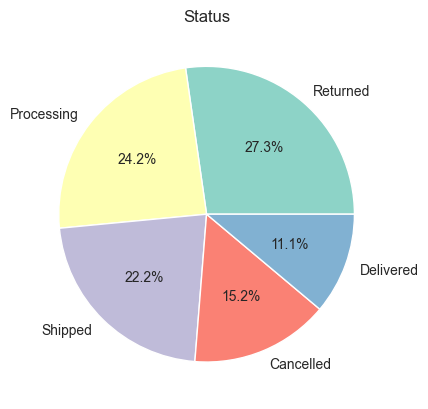

In [174]:
status_counts = ecommerce_dataset["Status"].value_counts()
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%"
)
plt.title("Status")
plt.show()

From the pie chart, we can observe that the majority of orders fall into the following statuses:

* Processing
* Shipped
* Returned

These categories dominate the dataset, indicating that most orders are either in progress, completed in transit, or have been returned.

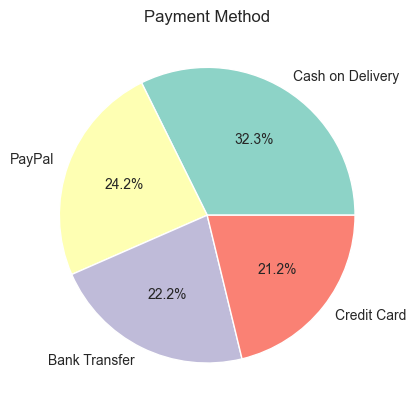

In [175]:
payment_method_counts = ecommerce_dataset["Payment_Method"].value_counts()
plt.pie(
    payment_method_counts,
    labels=payment_method_counts.index,
    autopct="%1.1f%%"
)
plt.title("Payment Method")
plt.show()

From the pie chart, we can observe that Cash on Delivery (COD) is the most frequently used payment method.

The remaining online payment methods are relatively evenly distributed, with no single method dominating among them.

### Most sold category and product

Text(0, 0.5, 'Category')

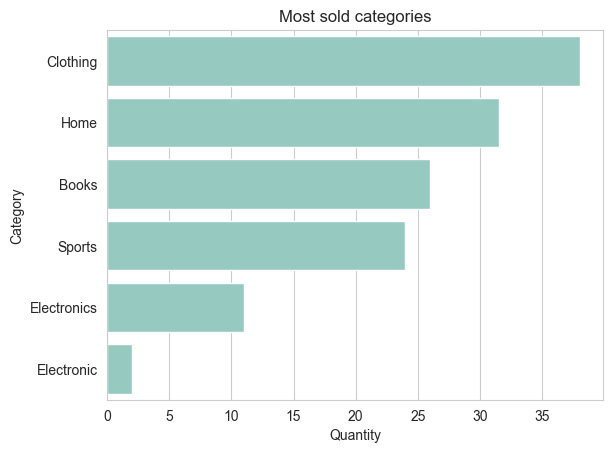

In [176]:
ecommerce_dataset_most_sold_mask = ecommerce_dataset[
    (
        ecommerce_dataset["Status"] == "Delivered"
    ) |
    (
        (ecommerce_dataset["Status"].isin(["Processing", "Shipped"])) &
        (ecommerce_dataset["Payment_Method"] != "Cash on Delivery")
    )
]

most_sold_categories = (
    ecommerce_dataset_most_sold_mask
    .groupby("Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sn.barplot(
    data=most_sold_categories,
    x="Quantity",
    y="Category"
)

plt.title("Most sold categories")
plt.xlabel("Quantity")
plt.ylabel("Category")

The most sold category in the dataset is Clothing, indicating it represents the largest share of total orders.

Text(0, 0.5, 'Product')

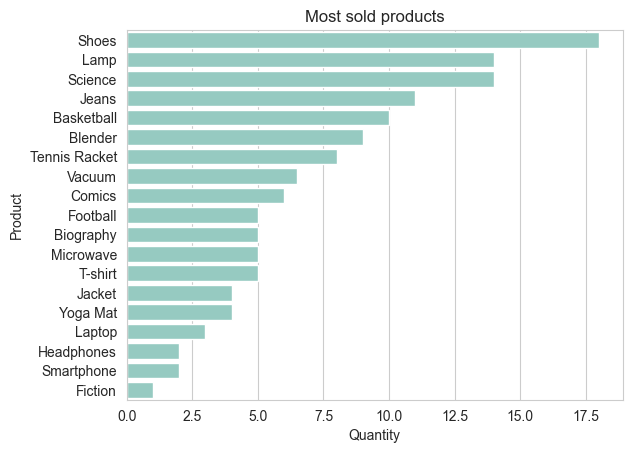

In [177]:
most_sold_products = (
    ecommerce_dataset_most_sold_mask
    .groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sn.barplot(
    data=most_sold_products,
    x="Quantity",
    y="Product"
)

plt.title("Most sold products")
plt.xlabel("Quantity")
plt.ylabel("Product")

The most sold product in the dataset is Shoes, by a significant margin compared to other products.

### Sales over time in 2025

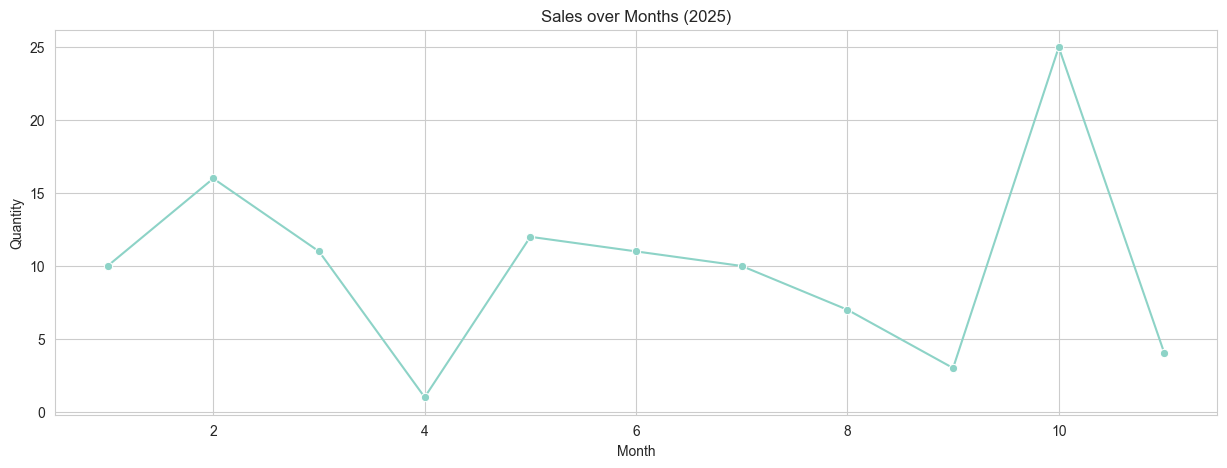

In [178]:
is_2025 = ecommerce_dataset["Order_Date"].dt.year == 2025

is_valid_status = (
    (ecommerce_dataset["Status"] == "Delivered") |
    (
        ecommerce_dataset["Status"].isin(["Processing", "Shipped"]) &
        (ecommerce_dataset["Payment_Method"] != "Cash on Delivery")
    )
)

ecommerce_dataset_monthly_sales_mask = ecommerce_dataset[is_2025 & is_valid_status]

ecommerce_dataset_monthly_sales = (
    ecommerce_dataset_monthly_sales_mask
    .groupby(ecommerce_dataset_monthly_sales_mask["Order_Date"].dt.month)["Quantity"]  # ← fixed
    .sum()
    .reset_index(name="Quantity")
    .rename(columns={"Order_Date": "Month"})
)

plt.figure(figsize=(15, 5))
sn.lineplot(
    data=ecommerce_dataset_monthly_sales,
    x="Month",
    y="Quantity",
    marker="o"
)
plt.title("Sales over Months (2025)")
plt.show()

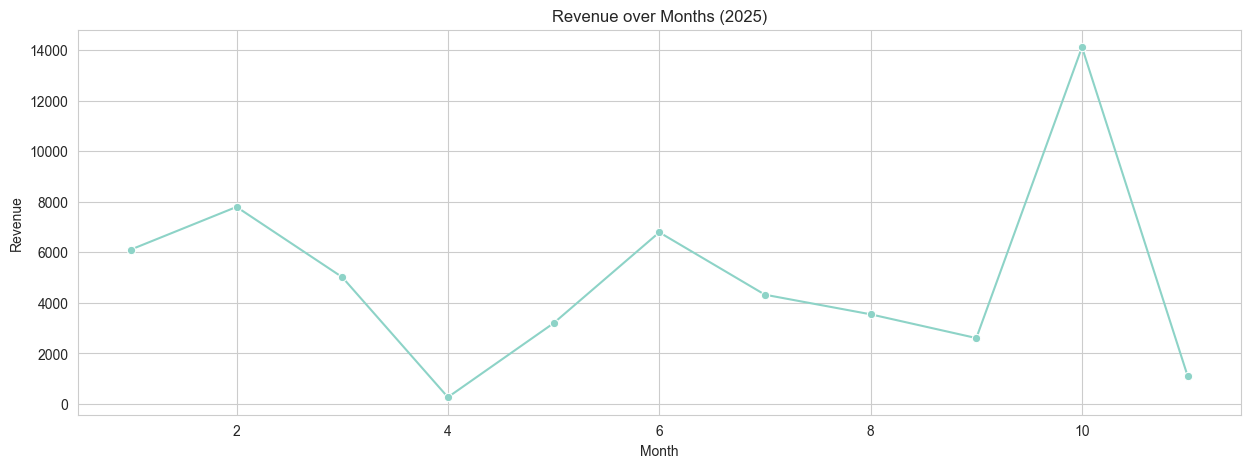

In [179]:
ecommerce_dataset_monthly_sales = (
    ecommerce_dataset_monthly_sales_mask
    .assign(Revenue = ecommerce_dataset_monthly_sales_mask["Quantity"] * ecommerce_dataset_monthly_sales_mask["Price"])
    .groupby(ecommerce_dataset_monthly_sales_mask["Order_Date"].dt.month)["Revenue"]
    .sum()
    .reset_index(name="Revenue")
    .rename(columns={"Order_Date": "Month"})
)

plt.figure(figsize=(15, 5))
sn.lineplot(
    data=ecommerce_dataset_monthly_sales,
    x="Month",
    y="Revenue",
    marker="o"
)
plt.title("Revenue over Months (2025)")
plt.show()

We can observe a noticeable spike in revenue and quantity sold in October (month 10), indicating a significant increase in sales activity during that period.

### Returned items

In [180]:
pd.crosstab(ecommerce_dataset["Status"], ecommerce_dataset["Category"])

Category,Books,Clothing,Electronic,Electronics,Home,Sports
Status,,,,,,
Cancelled,3,2,1,4,2,3
Delivered,0,2,0,4,2,3
Processing,6,5,1,3,4,5
Returned,10,3,0,4,5,5
Shipped,4,4,1,4,7,2


In [181]:
filtered_products = ecommerce_dataset[ecommerce_dataset["Category"] == "Books"]
pd.crosstab(filtered_products["Status"], filtered_products["Product"])

Product,Biography,Comics,Fiction,Science
Status,,,,
Cancelled,1,2,0,0
Processing,1,1,1,3
Returned,2,2,4,2
Shipped,1,2,0,1


We can observe that the category with the highest number of returned products is Books (Fiction).

### Payment method and Status comparison

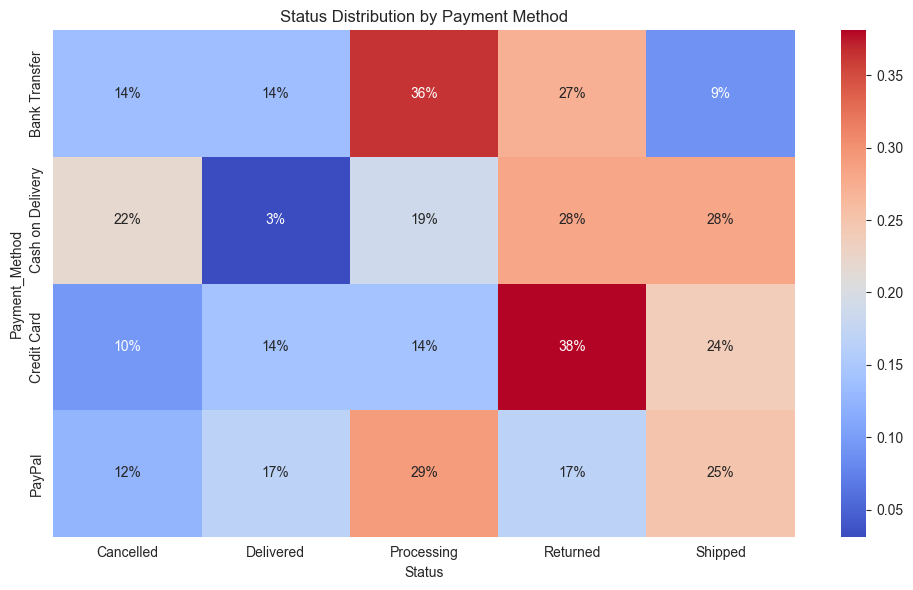

In [182]:
payment_method_status = pd.crosstab(
    ecommerce_dataset["Payment_Method"],
    ecommerce_dataset["Status"],
    normalize="index"
)

plt.figure(figsize=(10, 6))
sn.heatmap(payment_method_status, annot=True, fmt=".0%", cmap="coolwarm")
plt.title("Status Distribution by Payment Method")
plt.tight_layout()
plt.show()

From the analysis, we observe:

* A higher concentration of Bank Transfer payments in the Processing status
* PayPal also shows a strong presence across Processing order statuses
* A notable pattern where most Returned orders are associated with Credit Card
* A notable pattern where most Canceled orders are associated with Cash on Delivery (COD)

This may suggest that orders using Cash on Delivery are more prone to cancellation, possibly because the payment is not completed upfront.

### Price and Quantity relation

Correlation coefficient: 0.067


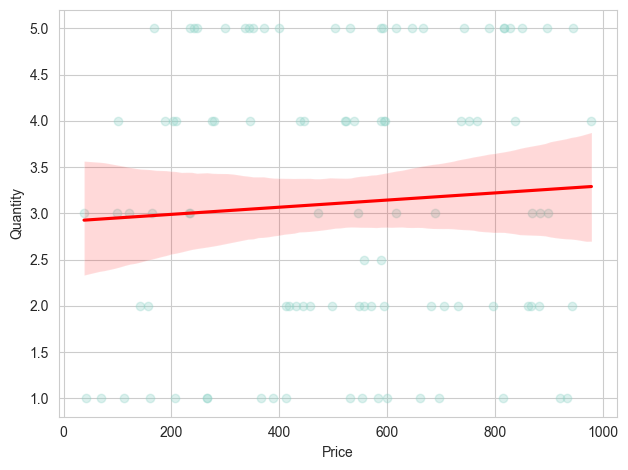

In [183]:
r = ecommerce_dataset[["Price", "Quantity"]].corr().loc["Price", "Quantity"]
print(f"Correlation coefficient: {r:.3f}")

sn.regplot(
    data=ecommerce_dataset,
    x="Price",
    y="Quantity",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.tight_layout()
plt.show()

The correlation between **Price** and **Quantity** is very low, indicating a weak linear relationship between the two variables.

This suggests that price has minimal impact on the quantity sold within this dataset.

## **CONCLUSION**

This exploratory data analysis was conducted on a messy e-commerce dataset with the goal of understanding its structure, identifying data quality issues, and extracting initial business insights. During the analysis, several common real-world data problems were identified, including missing values, inconsistent formatting, incorrect data types, duplicates, and outliers.

From an analytical perspective, the dataset revealed several meaningful patterns in customer behavior and sales distribution, including differences in product popularity, payment preferences, and temporal fluctuations in sales activity. However, while these trends provide useful initial insights, the dataset is relatively small and limited in scope. As a result, it is difficult to confidently generalize these patterns or conclude that they fully represent real-world behavior.

The dataset is useful for basic exploratory analysis, but it could be improved with more information to make the patterns more reliable and meaningful.
For example:
* adding customer details (e.g. age, gender), or location would allow for better segmentation and understanding of buying behavior
* including more time information, such as exact order time or delivery date
* product-related data (e.g. brand) etc.